In [1]:
import pandas as pd

columns = [
    "player_id",
    "player_name",
    "matches_played",
    "total_runs",
    "balls_faced",
    "total_fours",
    "total_sixes",
    "strike_rate",
    "centuries",
    "half_centuries",
    "ducks",
    "total_wickets",
    "bowling_economy",
    "performance_score",
    "auction_value"
]

df = pd.read_csv("/content/Results 39.csv", header=None, names=columns)

df.head()

,player_id,player_name,matches_played,total_runs,balls_faced,total_fours,total_sixes,strike_rate,centuries,half_centuries,ducks,total_wickets,bowling_economy,performance_score,auction_value
0,1,AJ Finch,90,2092,1635,214,78,127.95,0,15,7,1,10.858,1140.60,1.50
1,2,AM Rahane,171,4642,3761,479,103,123.42,2,30,13,1,5.000,2380.14,0.50
2,3,AT Rayudu,185,4348,3409,359,173,127.54,1,22,13,0,0.000,2298.95,6.75
3,4,BB McCullum,109,2882,2190,293,130,131.60,2,13,6,0,0.000,1579.96,3.60
4,5,CA Pujara,22,390,391,50,4,99.74,0,1,1,0,0.000,181.97,1.90


## 1. Load the Dataset
This cell loads the 39-player auction dataset from CSV and assigns the correct column names because the exported CSV did not contain headers.

In [4]:
print("Rows and columns:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Rows and columns: (39, 15)

Columns:
Index(['player_id', 'player_name', 'matches_played', 'total_runs',
       'balls_faced', 'total_fours', 'total_sixes', 'strike_rate', 'centuries',
       'half_centuries', 'ducks', 'total_wickets', 'bowling_economy',
       'performance_score', 'auction_value'],
      dtype='object')

Missing values:
player_id            0
player_name          0
matches_played       0
total_runs           0
balls_faced          0
total_fours          0
total_sixes          0
strike_rate          0
centuries            0
half_centuries       0
ducks                0
total_wickets        0
bowling_economy      0
performance_score    0
auction_value        0
dtype: int64


## 2. Validate the Dataset
We check the number of rows and columns, column names, data types, and missing values. The expected result is 39 rows, 15 columns, and no missing values.

In [5]:
feature_columns = [
    "matches_played",
    "total_runs",
    "balls_faced",
    "total_fours",
    "total_sixes",
    "strike_rate",
    "centuries",
    "half_centuries",
    "ducks",
    "total_wickets",
    "bowling_economy",
    "performance_score"
]

X = df[feature_columns]
y = df["auction_value"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (39, 12)
Target shape: (39,)


## 3. Select Features and Target
The 12 performance columns are used as model inputs (X). `auction_value` is the target (y) that the model will predict. Player ID and name are not used as model features.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (31, 12)
Testing data: (8, 12)


## 4. Train-Test Split
The data is split into 80% training data and 20% testing data using `random_state=42`, as required by the project.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:", X_train_scaled.shape)
print("Testing data after scaling:", X_test_scaled.shape)

Training data after scaling: (31, 12)
Testing data after scaling: (8, 12)


## 5. Feature Scaling
StandardScaler puts the numerical features on a comparable scale. The scaler is fitted only on the training data and then applied to both training and test data to avoid data leakage.

In [8]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 6. Linear Regression
Linear Regression is used as the simple baseline model. It learns a basic relationship between player performance features and auction value.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MAE : 2.900186120291967
RMSE: 4.326844480557389
R²  : -0.21662845106072415


## 7. Evaluate Linear Regression
MAE measures the average absolute prediction error, RMSE gives more weight to large errors, and R² measures how much variation in auction value the model explains.

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 8. Random Forest
Random Forest is a tree-based regression model that can learn more complex relationships between performance features and auction value.

In [11]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 2.848725
RMSE: 4.167428754040073
R²  : -0.12863045414091112


## 9. Evaluate Random Forest
We calculate MAE, RMSE, and R² for the Random Forest using the unseen test players.

In [12]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## 10. XGBoost
XGBoost is another tree-based regression model. It is tested so that we can compare three different approaches.

In [13]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost
MAE : 2.9968785524368284
RMSE: 4.592903701098044
R²  : -0.37085044190929684


## 11. Evaluate XGBoost
The XGBoost predictions are evaluated with the same MAE, RMSE, and R² metrics so the three models can be compared fairly.

## Model Comparison

| Model | MAE (Cr) | RMSE (Cr) | R² |
|---|---:|---:|---:|
| Linear Regression | 2.900 | 4.327 | -0.217 |
| Random Forest | 2.849 | 4.167 | -0.129 |
| XGBoost | 2.997 | 4.593 | -0.371 |

The initial Random Forest is the strongest baseline among the three models. We then tune Random Forest and evaluate the tuned version on the untouched test set.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [2, 3, 5],
    "min_samples_leaf": [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error"
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)

Best parameters: {'max_depth': 2, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV MAE: 2.7416594687285754


## 12. Tune Random Forest
GridSearchCV tests a small set of Random Forest settings using only the training data with 5-fold cross-validation. This helps choose settings that generalize better without using the test set for tuning.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tuned_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=2,
    min_samples_leaf=3,
    random_state=42
)

tuned_rf.fit(X_train_scaled, y_train)

y_pred_tuned = tuned_rf.predict(X_test_scaled)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned Random Forest
MAE : 2.6586310137874447
RMSE: 3.907061631730384
R²  : 0.007990294820272248


## 13. Evaluate the Tuned Random Forest
The tuned model is trained with the best settings found during cross-validation and then evaluated on the untouched test set. This is our final model evaluation.

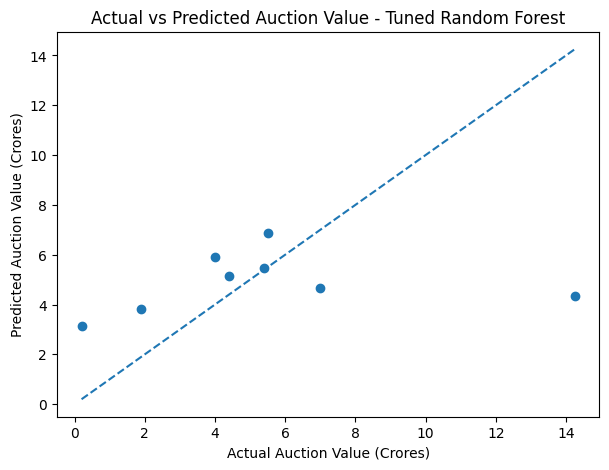

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_tuned)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Auction Value (Crores)")
plt.ylabel("Predicted Auction Value (Crores)")
plt.title("Actual vs Predicted Auction Value - Tuned Random Forest")

plt.show()

## 14. Actual vs Predicted
This graph compares the real auction values with the tuned Random Forest predictions. Points closer to the diagonal line represent better predictions.

In [21]:
sample_players = df.head(5)

X_sample = sample_players[feature_columns]

X_sample_scaled = scaler.transform(X_sample)

predicted_values = tuned_rf.predict(X_sample_scaled)

prediction_results = pd.DataFrame({
    "Player": sample_players["player_name"],
    "Actual Auction Value": sample_players["auction_value"],
    "Predicted Auction Value": predicted_values
})

print(prediction_results)

        Player  Actual Auction Value  Predicted Auction Value
0     AJ Finch                  1.50                 3.166207
1    AM Rahane                  0.50                 3.355616
2    AT Rayudu                  6.75                 5.733249
3  BB McCullum                  3.60                 5.212133
4    CA Pujara                  1.90                 3.834923


## 15. Five Player Predictions
The final Tuned Random Forest is used to estimate auction values for five real players from the dataset.

In [22]:
final_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": tuned_rf.feature_importances_
})

final_feature_importance = final_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(final_feature_importance)

              Feature  Importance
5         strike_rate    0.299827
0      matches_played    0.194293
4         total_sixes    0.117839
10    bowling_economy    0.082159
11  performance_score    0.076900
2         balls_faced    0.066836
9       total_wickets    0.062685
7      half_centuries    0.034245
1          total_runs    0.028915
8               ducks    0.021163
3         total_fours    0.009355
6           centuries    0.005782


## 16. Final Feature Importance
This ranks the performance features according to how much the final Tuned Random Forest used them when making predictions.

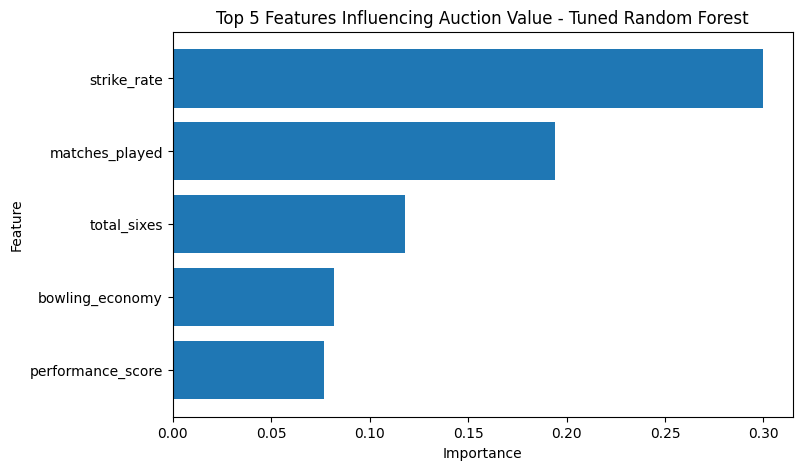

In [23]:
top_5_final = final_feature_importance.head(5)

plt.figure(figsize=(8, 5))

plt.barh(top_5_final["Feature"], top_5_final["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 5 Features Influencing Auction Value - Tuned Random Forest")

plt.gca().invert_yaxis()

plt.show()

## 17. Top Five Feature Importance
This graph shows the five most influential features from the final model.

## Final ML Findings

This project was developed to estimate IPL player auction value using historical player performance statistics. The model used 39 players who had a valid auction or RTM purchase value. Virat Kohli was excluded from the ML dataset because his available ₹0.12 crore value was from the U19 draft rather than a genuine auction or RTM purchase.

The input features used for prediction were matches played, total runs, balls faced, total fours, total sixes, strike rate, centuries, half-centuries, ducks, total wickets, bowling economy, and performance score. The target variable was auction value in crores.

Three regression models were tested: Linear Regression, Random Forest, and XGBoost. Initially, Linear Regression produced an MAE of 2.90 crores, RMSE of 4.33 crores, and an R² of -0.217. Random Forest performed slightly better, with an MAE of 2.85 crores, RMSE of 4.17 crores, and an R² of -0.129. XGBoost produced an MAE of 3.00 crores, RMSE of 4.59 crores, and an R² of -0.371.

Random Forest was then tuned by testing different model settings. The tuned Random Forest achieved an MAE of 2.66 crores, RMSE of 3.91 crores, and an R² of 0.008. Therefore, the tuned Random Forest was selected as the best model among the three tested models.

The feature importance analysis showed that strike rate was the most influential feature in the tuned Random Forest model. Matches played, total sixes, bowling economy, and performance score were the next four most influential features. This suggests that the model gave relatively more importance to scoring ability, experience, power hitting, bowling efficiency, and overall performance.

However, the model has an important limitation. Only 39 players were available for training, and the test set contained only 8 players. Auction values also vary widely because real auctions are influenced by factors such as team requirements, player availability, market conditions, and other factors that are not included in our dataset. Because of this, the model should be viewed as an academic estimation system rather than a system that can guarantee real IPL auction prices.

Overall, this project demonstrates how SQL can be used to prepare structured IPL data and how Python and machine learning can use player performance statistics to estimate auction value.

## 18. Final Findings
The final findings summarize the model comparison, important features, limitations, and the overall project conclusion.